<>:34: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\$'
<>:34: SyntaxWarning: invalid escape sequence '\$'
<>:37: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_4179/3174050206.py:34: SyntaxWarning: invalid escape sequence '\$'
  df["price"] = df["price"].replace('[\$,]', '', regex=True)
/tmp/ipykernel_4179/3174050206.py:37: SyntaxWarning: invalid escape sequence '\$'
  df["service_fee"] = df["service_fee"].replace('[\$,]', '', regex=True)
/tmp/ipykernel_4179/3174050206.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perf

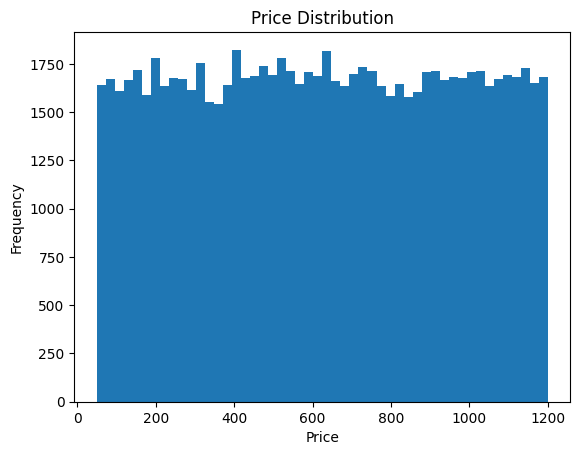

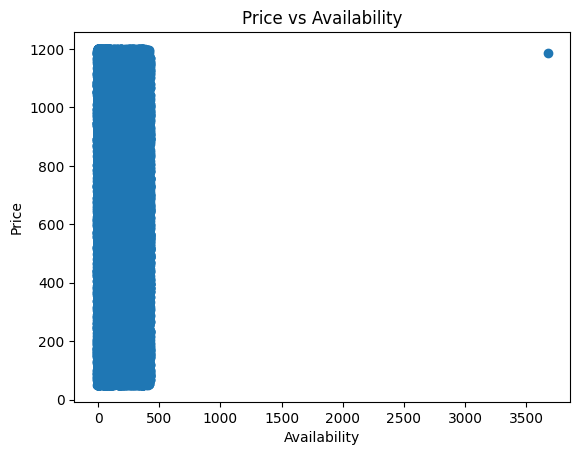

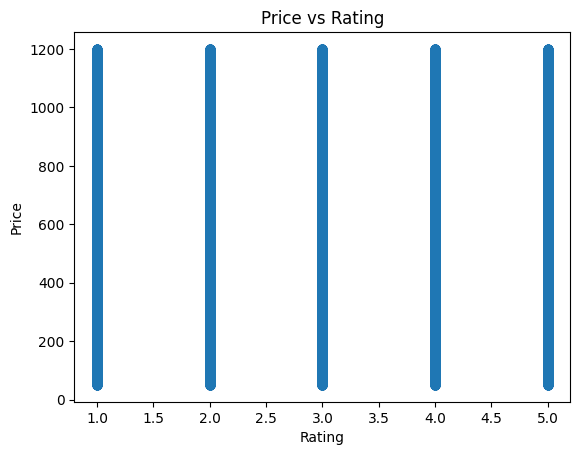

/tmp/ipykernel_4179/3174050206.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("availability_level")["price"].mean()


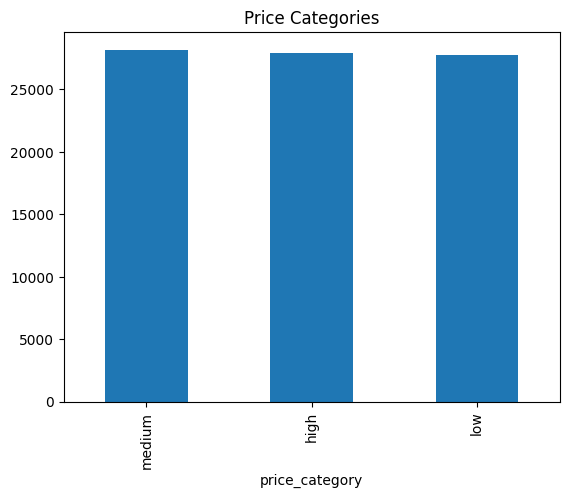

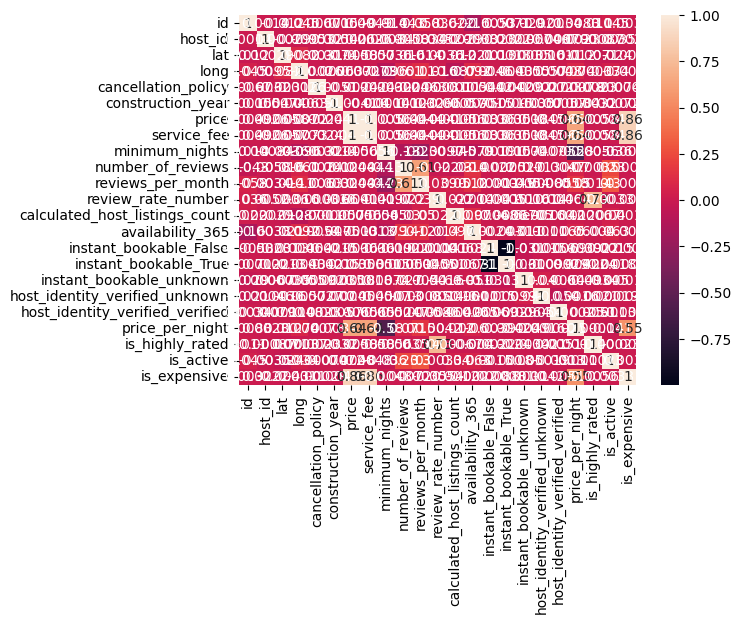

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder


data=pd.read_csv("/content/airbnb_raw_data.csv",low_memory=False)
df=pd.DataFrame(data)

df.columns = df.columns.str.lower().str.replace(" ", "_")

df["name"].fillna("unknown",inplace=True)
df["host_name"].fillna("unknown",inplace=True)
df["host_identity_verified"].fillna("unknown",inplace=True)
df["neighbourhood"].fillna("unknown",inplace=True)
df["neighbourhood_group"].fillna("unknown",inplace=True)
df["calculated_host_listings_count"].fillna(df['calculated_host_listings_count'].median(),inplace=True)
df = df.dropna(subset=["lat", "long"])
df.drop("country_code", axis=1, inplace=True)
df["instant_bookable"].fillna("unknown", inplace=True)
df = pd.get_dummies(df, columns=["instant_bookable"])
df["construction_year"].fillna(df['construction_year'].median(),inplace=True)
df = df.dropna(subset=["price"])
df = df.dropna(subset=["service_fee"])
df["minimum_nights"].fillna(df["minimum_nights"].median(), inplace=True)
df = df.drop(columns=["last_review_date"],errors="ignore")
df["reviews_per_month"].fillna(0, inplace=True)
df["review_rate_number"].fillna(df["review_rate_number"].median(), inplace=True)
df["availability_365"].fillna(df["availability_365"].median(), inplace=True)
df['house_rules'].fillna('none', inplace=True)
df=df.drop(columns=["license"],errors="ignore")

df["price"] = df["price"].replace('[\$,]', '', regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

df["service_fee"] = df["service_fee"].replace('[\$,]', '', regex=True)
df["service_fee"] = pd.to_numeric(df["service_fee"], errors="coerce")

df=df.dropna(subset=["price","service_fee"])

def remove_outliers(df,column):
  Q1=np.quantile(df[column],0.25)
  Q3=np.quantile(df[column],0.75)
  IQR=Q3-Q1

  lower_bound=Q1-IQR*1.5
  upper_bound=Q3+IQR*1.5
  return df[(df[column]>=lower_bound) & (df[column]<=upper_bound)]

df = remove_outliers(df, "price")
df = remove_outliers(df, "service_fee")
df = remove_outliers(df, "minimum_nights")

df=pd.get_dummies(df,columns=["host_identity_verified"],drop_first=True)

mapping = {
    "flexible": 0,
    "moderate": 1,
    "strict": 2
}

df["cancellation_policy"] = df["cancellation_policy"].map(mapping)


df["price_per_night"] = df["price"] / df["minimum_nights"]

df["availability_level"] = pd.cut(
    df["availability_365"],
    bins=[0, 50, 200, 365],
    labels=["low", "medium", "high"]
)
df["is_highly_rated"] = df["review_rate_number"] >= 4.5

df["is_active"] = df["reviews_per_month"] > 0

df["host_experience"] = pd.cut(
    df["calculated_host_listings_count"],
    bins=[0, 1, 5, 20, 100],
    labels=["new", "small", "experienced", "professional"]
)
df["is_expensive"] = df["price"] > df["price"].median()

df["price_category"] = pd.cut(
    df["price"],
    bins=3,
    labels=["low", "medium", "high"]
)



plt.hist(df["price"],bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

plt.scatter(df["availability_365"], df["price"])
plt.xlabel("Availability")
plt.ylabel("Price")
plt.title("Price vs Availability")
plt.show()

plt.scatter(df["review_rate_number"], df["price"])
plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Price vs Rating")
plt.show()

df.groupby("availability_level")["price"].mean()

df["price_category"].value_counts().plot(kind="bar")
plt.title("Price Categories")
plt.show()


sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()